In [ ]:
# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("spotify-2023.csv", encoding="ISO-8859-1")

spotify = df.copy()
spotify.columns = spotify.columns.str.strip().str.lower().str.replace(" ", "_")

for col in ["bpm", "danceability_%", "energy_%", "speechiness_%", "acousticness_%"]:
    spotify[col] = pd.to_numeric(spotify[col], errors="coerce")

spotify = spotify.dropna(subset=["bpm", "key", "mode", "energy_%"])

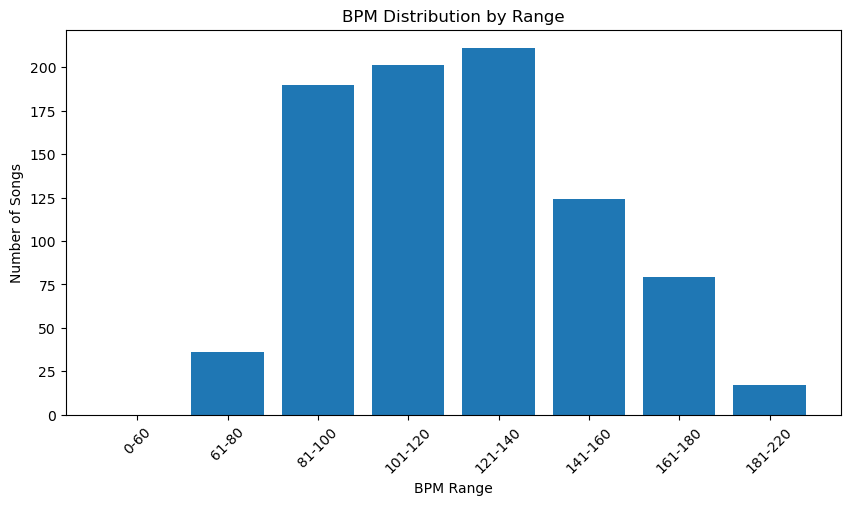

bpm_range
0-60         0
61-80       36
81-100     190
101-120    201
121-140    211
141-160    124
161-180     79
181-220     17
Name: count, dtype: int64


In [4]:
bpm_bins = [0, 60, 80, 100, 120, 140, 160, 180, 220]
bpm_labels = ["0-60", "61-80", "81-100", "101-120", "121-140", "141-160", "161-180", "181-220"]

spotify["bpm_range"] = pd.cut(spotify["bpm"], bins=bpm_bins, labels=bpm_labels, include_lowest=True)

bpm_counts = spotify["bpm_range"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(bpm_counts.index.astype(str), bpm_counts.values)
plt.title("BPM Distribution by Range")
plt.xlabel("BPM Range")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

print(bpm_counts)



Over 200 top songs were made with between 121-140 Bpm.

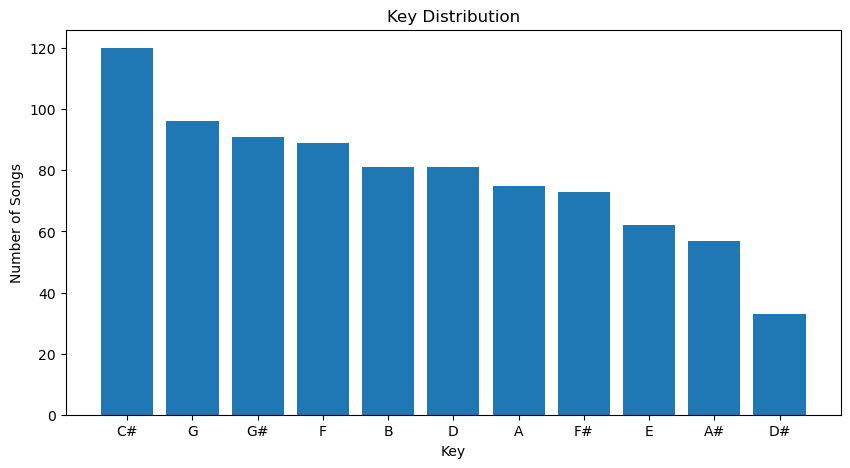

key
C#    120
G      96
G#     91
F      89
B      81
D      81
A      75
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64


In [5]:
key_counts = spotify["key"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(key_counts.index.astype(str), key_counts.values)
plt.title("Key Distribution")
plt.xlabel("Key")
plt.ylabel("Number of Songs")
plt.show()

print(key_counts)

Just about 120 songs were made in C#

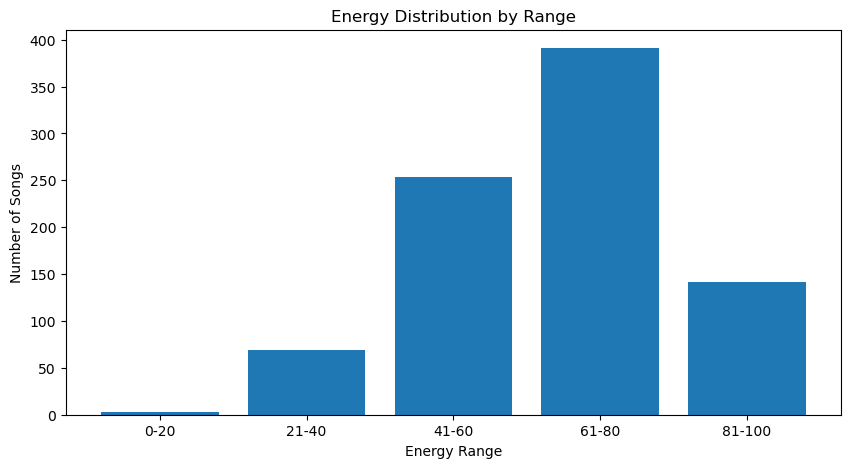

energy_range
0-20        3
21-40      69
41-60     253
61-80     391
81-100    142
Name: count, dtype: int64


In [6]:
energy_bins = [0, 20, 40, 60, 80, 100]
energy_labels = ["0-20", "21-40", "41-60", "61-80", "81-100"]

spotify["energy_range"] = pd.cut(spotify["energy_%"], bins=energy_bins, labels=energy_labels, include_lowest=True)

energy_counts = spotify["energy_range"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(energy_counts.index.astype(str), energy_counts.values)
plt.title("Energy Distribution by Range")
plt.xlabel("Energy Range")
plt.ylabel("Number of Songs")
plt.show()

print(energy_counts)

Over 350 songs were made with 61-80% energy

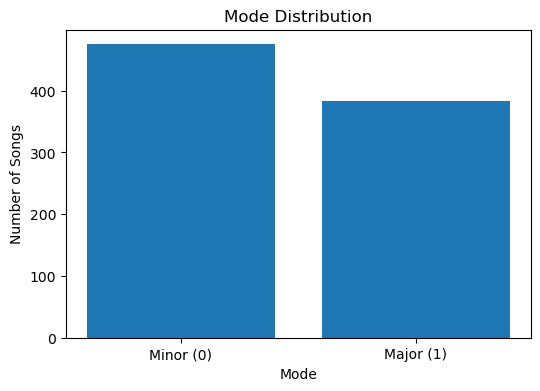

mode
Major    475
Minor    383
Name: count, dtype: int64


In [15]:
mode_counts = spotify["mode"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(mode_counts.index.astype(str), mode_counts.values)
plt.title("Mode Distribution")
plt.xlabel("Mode")
plt.ylabel("Number of Songs")
plt.xticks([0, 1], ["Minor (0)", "Major (1)"])
plt.show()

print(mode_counts)

Over 400 songs were made in the minor scale

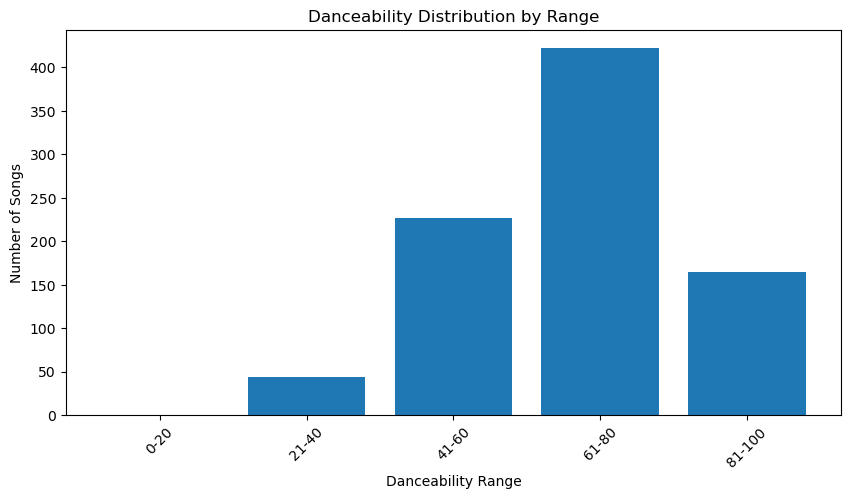

dance_range
0-20        0
21-40      44
41-60     227
61-80     422
81-100    165
Name: count, dtype: int64


In [8]:
dance_bins = [0, 20, 40, 60, 80, 100]
dance_labels = ["0-20", "21-40", "41-60", "61-80", "81-100"]

spotify["dance_range"] = pd.cut(
    spotify["danceability_%"],
    bins=dance_bins,
    labels=dance_labels,
    include_lowest=True
)

dance_counts = spotify["dance_range"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(dance_counts.index.astype(str), dance_counts.values)
plt.title("Danceability Distribution by Range")
plt.xlabel("Danceability Range")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

print(dance_counts)

Danceability is high in the 61-80% range with over 400 songs included.

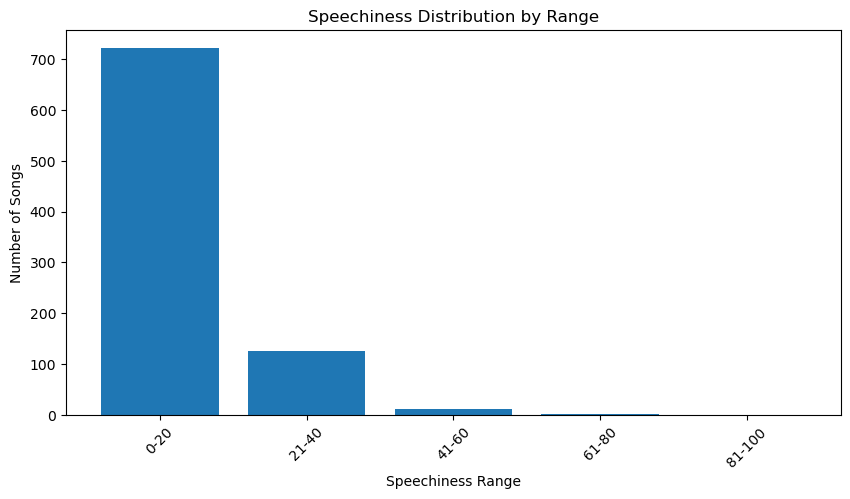

speech_range
0-20      721
21-40     125
41-60      11
61-80       1
81-100      0
Name: count, dtype: int64


In [9]:
speech_bins = [0, 20, 40, 60, 80, 100]
speech_labels = ["0-20", "21-40", "41-60", "61-80", "81-100"]

spotify["speech_range"] = pd.cut(
    spotify["speechiness_%"],
    bins=speech_bins,
    labels=speech_labels,
    include_lowest=True
)

speech_counts = spotify["speech_range"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(speech_counts.index.astype(str), speech_counts.values)
plt.title("Speechiness Distribution by Range")
plt.xlabel("Speechiness Range")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

print(speech_counts)

0-20% speechiness for over 700 songs.

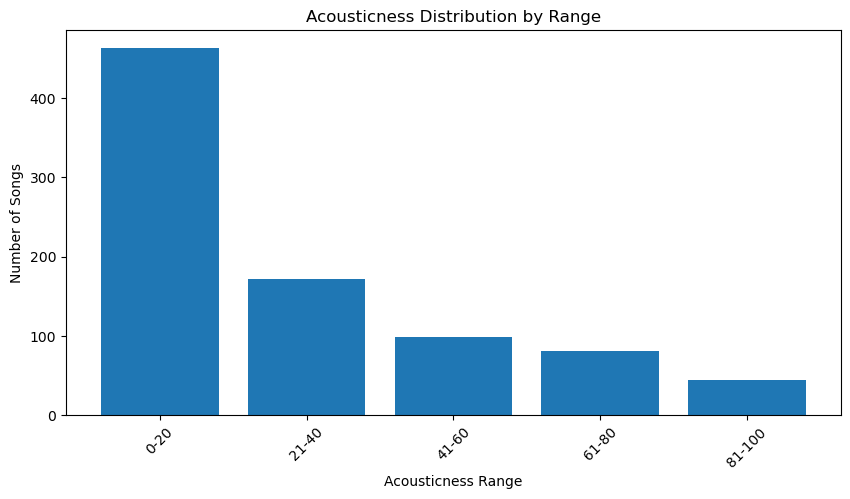

acoustic_range
0-20      463
21-40     172
41-60      98
61-80      81
81-100     44
Name: count, dtype: int64


In [10]:
acoustic_bins = [0, 20, 40, 60, 80, 100]
acoustic_labels = ["0-20", "21-40", "41-60", "61-80", "81-100"]

spotify["acoustic_range"] = pd.cut(
    spotify["acousticness_%"],
    bins=acoustic_bins,
    labels=acoustic_labels,
    include_lowest=True
)

acoustic_counts = spotify["acoustic_range"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(acoustic_counts.index.astype(str), acoustic_counts.values)
plt.title("Acousticness Distribution by Range")
plt.xlabel("Acousticness Range")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

print(acoustic_counts)

In [ ]:
Over 400 songs were great for acousticness for the top songs.

In [16]:
engineered_songs = df.loc[
    (df['key'] == 'A') &
    (df['bpm'] >= 120) &
    (df['bpm'] <= 140) &
    (df['mode'] == 'Major') &
    (df['danceability_%'] >= 60) &
    (df['danceability_%'] <= 80) &
    (df['energy_%'] >= 60) &
    (df['energy_%'] <= 80) &
    (df['speechiness_%'] >= 0) &
    (df['speechiness_%'] <= 20) &
    (df['acousticness_%'] >= 0) &
    (df['acousticness_%'] <= 20)
]

engineered_songs[['track_name', 'artist(s)_name', 'key', 'bpm', 'mode',
                  'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']]

,track_name,artist(s)_name,key,bpm,mode,danceability_%,energy_%,speechiness_%,acousticness_%
637,Permission to Dance,BTS,A,125,Major,70,74,4,1


BTS made Permission to Dance meets all the requirements for top song and it is a popular song by a popular group.

In [26]:
Woah = df.loc[
    (df['track_name'].str.lower() == 'lose yourself - soundtrack version')
]

Woah[['track_name', 'artist(s)_name', 'key', 'bpm', 'mode',
      'danceability_%', 'energy_%', 'speechiness_%', 'acousticness_%']]

,track_name,artist(s)_name,key,bpm,mode,danceability_%,energy_%,speechiness_%,acousticness_%
296,Lose Yourself - Soundtrack Version,Eminem,D,171,Major,70,73,26,1


Overall, Permission to Dance is the closer match to the data based hit formula, while Lose Yourself . still shares some popular features but stands out more because of its faster tempo and higher speechiness. This shows that a song can still be a major hit even if it does not perfectly match the most common pattern in the dataset.